# STL Features

STL stands for **Seasonal-Trend decomposition using Loess**; (Loess is a reggression model). It is a widely used decomposition method; which splits each series into three parts:

$$ y_t = T_t + S_t + R_t $$

- **trend-cycle component** $T_t$
- **seasonal component** $S_t$
- **remainder component** $R_t$ (includes everything else that we couldn't contribute to the other two)

From these, mathematicians derived two features:

$$F_T = \max\left(0,\ 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(T_t + R_t)}\right), \qquad F_S = \max\left(0,\ 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t + R_t)}\right).$$

Where:

- $F_T \in [0, 1]$: a measure of the **strength of the trend**. In layman terms: "how clearly it's heading somewhere".
- $F_S \in [0, 1]$: a measure of the **strength of seasonality**. That is: "how reliably it repeats its yearly rhythm".

Each expressed as _fraction of movement that's real pattern rather than noise_. If both are low; it indicates randomness.

![Figure: Several raw time series from the M1- and M3-Competition [[7](https://encyclopedia.pub/entry/46431#ref_7)], which have different characteristics regarding the trend and seasonal strength. Values were rounded to two decimal places. Trend strength and seasonal strength were computed using feasts 0.1.6](../assets/trend_and_seasonal_strength.png){height=500}

Figure: Several raw time series from the M1- and M3-Competition [[7](https://encyclopedia.pub/entry/46431#ref_7)], which have different characteristics regarding the trend and seasonal strength. Values were rounded to two decimal places. Trend strength and seasonal strength were computed using feasts 0.1.6.

Source: Zimmerer, E., Schmider, F., & Böhm, K. (2023). Information Extraction from Industrial Sensor Data Using Time Series Meta-Features. *Applied Sciences*, 13(12), 7065. https://doi.org/10.3390/app13127065 Link: https://www.mdpi.com/2076-3417/13/12/7065

## Loading and Preprocessing the Dataset

In [63]:
from pathlib import Path
import sys

# Make local imports work for this notebook
LESSON_DIR = Path().resolve()
COURSE_DIR = LESSON_DIR.parent
if str(COURSE_DIR) not in sys.path:
    sys.path.insert(0, str(COURSE_DIR))

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# set sns theme
sns.set_theme(style="whitegrid")

In [65]:
from utils import load_tourism

tourism = load_tourism()

# Flatten the multi-index structure
tourism_flat = tourism.reset_index()

# Convert the "Quarter" column from a string to a timestamp
tourism_flat["Quarter"] = tourism_flat["Quarter"].dt.to_timestamp()

# String together the "unique_id" from the other columns
tourism_flat["unique_id"] = tourism_flat.apply(lambda row: f"{row['Region']}_{row['State']}_{row['Purpose']}", axis=1)

# one metadata row per series (reused when joining features)
series_keys = (
    tourism_flat
    .groupby("unique_id", as_index=False)
    .first()[["unique_id", "Region", "State", "Purpose"]]
)

tourism_panel = (
    tourism_flat
    .drop(columns=["Region", "State", "Purpose"])
    .rename(
        columns={
            "Quarter": "ds",
            "Trips": "y"
        }
    )
)[["unique_id", "ds", "y"]]

tourism_panel

,unique_id,ds,y
0,Adelaide_South Australia_Business,1998-01-01,135.077690
1,Adelaide_South Australia_Business,1998-04-01,109.987316
2,Adelaide_South Australia_Business,1998-07-01,166.034687
3,Adelaide_South Australia_Business,1998-10-01,127.160464
4,Adelaide_South Australia_Business,1999-01-01,137.448533
...,...,...,...
24315,Yorke Peninsula_South Australia_Visiting,2016-10-01,33.672151
24316,Yorke Peninsula_South Australia_Visiting,2017-01-01,46.223014
24317,Yorke Peninsula_South Australia_Visiting,2017-04-01,50.582837
24318,Yorke Peninsula_South Australia_Visiting,2017-07-01,27.766728


Now the data is ready to be processed by `tsfeatures`

## Feature Extraction

In [66]:
import tsfeatures

In [67]:
features = tsfeatures.tsfeatures(
    tourism_panel,
    freq=4,
    features=[tsfeatures.stl_features],
    scale=False,
)

In [68]:
features

,unique_id,nperiods,seasonal_period,trend,spike,linearity,curvature,e_acf1,e_acf10,seasonal_strength,peak,trough
0,Adelaide Hills_South Australia_Business,1,4,0.459551,0.109814,1.192588,-2.693697,-0.593983,0.501804,0.167862,3,4
1,Adelaide Hills_South Australia_Holiday,1,4,0.531073,0.172371,10.627940,24.997447,-0.456062,0.342397,0.295210,2,4
2,Adelaide Hills_South Australia_Other,1,4,0.589967,0.000397,4.103994,3.133187,-0.295031,0.272627,0.407474,2,2
3,Adelaide Hills_South Australia_Visiting,1,4,0.487016,7.550239,34.511713,-1.330737,-0.474299,0.437780,0.247725,4,3
4,Adelaide_South Australia_Business,1,4,0.461801,156.809601,-3.787861,73.041564,-0.537537,0.577152,0.390732,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
299,Wimmera_Victoria_Visiting,1,4,0.478595,0.200899,-6.448102,12.669234,-0.348798,0.268429,0.199773,2,3
300,Yorke Peninsula_South Australia_Business,1,4,0.431395,0.046316,-7.096716,-6.614168,-0.429625,0.338013,0.411324,3,1
301,Yorke Peninsula_South Australia_Holiday,1,4,0.449121,3.346870,20.469755,-4.218631,-0.498477,0.560237,0.829736,1,3
302,Yorke Peninsula_South Australia_Other,1,4,0.384407,0.003326,4.590706,4.152093,-0.648995,0.682795,0.314095,3,2


## Interpretation of `stl_features`

We can see at least two counts:

- `nperiods`: Number of seasonal periods observed in the series.
    - Remember in the Vectorian Electricity Demand data, we had 3: yearly, weekly, daily.
    - However, here we only have 1: yearly.
- `seasonal_period`: The frequency (here, quarterly = 4).

We can also see our **two primary features**:

- `trend` ($F_T \in [0, 1]$): Quantifies the strength of the trend component in the series, where higher values (closer to 1) indicate a more pronounced/important trend.
- `seasonal_strength` ($F_S \in [0, 1]$): Strength of seasonal component; higher values mean the seasonal pattern is more dominant.

This allows us to **rank** all 304 to find the most trended or the most seasonal destinations — something impossible to eyeball across hundreds of line plots.

In [69]:
features.sort_values(by="trend", ascending=False)[['unique_id', 'trend', 'seasonal_strength']]

,unique_id,trend,seasonal_strength
20,Australia's North West_Western Australia_Business,0.937747,0.430452
201,Melbourne_Victoria_Holiday,0.869509,0.341814
25,Australia's South West_Western Australia_Holiday,0.852686,0.878895
202,Melbourne_Victoria_Other,0.821921,0.162889
103,Experience Perth_Western Australia_Visiting,0.806635,0.364437
...,...,...,...
208,Murraylands_South Australia_Business,0.258399,0.175016
142,High Country_Victoria_Other,0.253955,0.122734
229,Outback NSW_New South Wales_Holiday,0.234950,0.746675
204,Murray East_Victoria_Business,0.228719,0.141025


In [70]:
features.sort_values(by="seasonal_strength", ascending=False)[['unique_id', 'trend', 'seasonal_strength']]

,unique_id,trend,seasonal_strength
253,Snowy Mountains_New South Wales_Holiday,0.625073,0.971558
137,Great Ocean Road_Victoria_Holiday,0.535688,0.954391
257,South Coast_New South Wales_Holiday,0.518852,0.950727
237,Peninsula_Victoria_Holiday,0.703452,0.938514
145,Hobart and the South_Tasmania_Holiday,0.595065,0.903393
...,...,...,...
142,High Country_Victoria_Other,0.253955,0.122734
262,Spa Country_Victoria_Other,0.357161,0.113088
138,Great Ocean Road_Victoria_Other,0.451388,0.107652
198,Melbourne East_Victoria_Other,0.472818,0.097409


We could nicely represent them visually usin a scatterplot. But, first, we need to get the original multi-indexed Dataframe rather than the flat named `unique_id`; since it is what pandas/seaborn work with:

In [71]:
two_features = ['trend', 'seasonal_strength']
tourism_features = features.merge(series_keys, on="unique_id")
tourism_features[["Region", "State", "Purpose"] + two_features]

,Region,State,Purpose,trend,seasonal_strength
0,Adelaide Hills,South Australia,Business,0.459551,0.167862
1,Adelaide Hills,South Australia,Holiday,0.531073,0.295210
2,Adelaide Hills,South Australia,Other,0.589967,0.407474
3,Adelaide Hills,South Australia,Visiting,0.487016,0.247725
4,Adelaide,South Australia,Business,0.461801,0.390732
...,...,...,...,...,...
299,Wimmera,Victoria,Visiting,0.478595,0.199773
300,Yorke Peninsula,South Australia,Business,0.431395,0.411324
301,Yorke Peninsula,South Australia,Holiday,0.449121,0.829736
302,Yorke Peninsula,South Australia,Other,0.384407,0.314095


We'll scatter `trend` against `seasonal_strength`, coloured by `Purpose` and faceted by `State`.

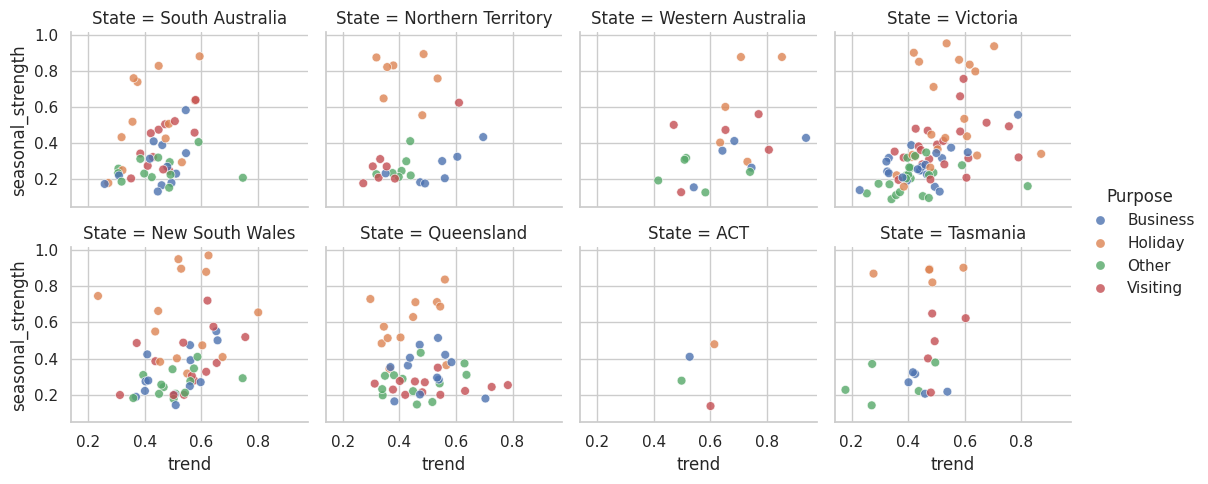

In [72]:
import seaborn as sns

trend_season_grid = sns.relplot(
    data=tourism_features,
    x="trend",                 # F_T — trend strength
    y="seasonal_strength",     # F_S — seasonal strength
    hue="Purpose",             # colour by travel purpose
    col="State",               # small multiples per state
    col_wrap=4,
    height=2.5,
    aspect=1.1,
    alpha=0.8,
    s=40,
)

Clearly, **Holiday** series are the most seasonal — unsurprising for tourism. The **strongest trends** tend to appear in **Western Australia** and **Victoria** (points with high `trend` in those facets).


### Zoom in on New South Wales

Our analysis revealed that **holiday** trips to Australia's main **ski region** (Snowy Mountains) has the most seasonality.


Let's visualize the time series for it, split by `Purpose` of trip:

<Axes: xlabel='Quarter', ylabel='Trips'>

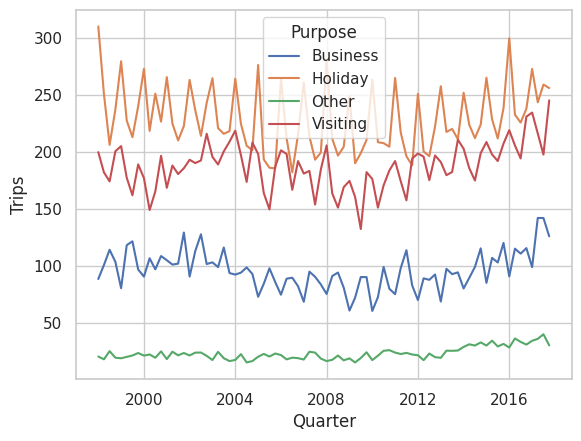

In [ ]:
ts_nsw = tourism_flat[tourism_flat["State"] == "New South Wales"]

sns.lineplot(
    data=ts_nsw,
    x="Quarter",
    y="Trips",
    hue="Purpose",
    legend=True,
    errorbar=None,
)

Quick observation: We see clear ranking; most visits to NSW is for Holidays (around 225,000 per quarter; on average across the years since 1990s until 2020). Followed by Visiting (about 175), then Business at 95, then the bottom being "Other" around 25.

Sense NSW shows high `seasonal_strength`; we can look further into features of $S_t$ the seasonal component:

- `peak`: Quarter (or period) with the highest seasonal component. "Which quarter is busiest?"
  
- `trough`: Quarter with the lowest seasonal component. "Which quarter is quietest?"

In [ ]:
nsw_features = tourism_features[tourism_features["State"] == "New South Wales"]

# Prepare single DataFrame for plotting, using vectorized assignment
peak = nsw_features[["peak", "Purpose"]].copy()
peak["Type"] = "Peak"
peak["Quarter"] = peak["peak"]
trough = nsw_features[["trough", "Purpose"]].copy()
trough["Type"] = "Trough"
trough["Quarter"] = trough["trough"]

peak_trough_purposes = pd.concat([
    peak[["Quarter", "Type", "Purpose"]],
    trough[["Quarter", "Type", "Purpose"]]
], axis=0, ignore_index=True)

peak_trough_purposes

,Quarter,Type,Purpose
0,2,Peak,Business
1,2,Peak,Holiday
2,1,Peak,Other
3,2,Peak,Visiting
4,3,Peak,Business
...,...,...,...
99,3,Trough,Visiting
100,1,Trough,Business
101,3,Trough,Holiday
102,3,Trough,Other


Text(0.5, 1.02, 'Seasonal visits to New South Wales')

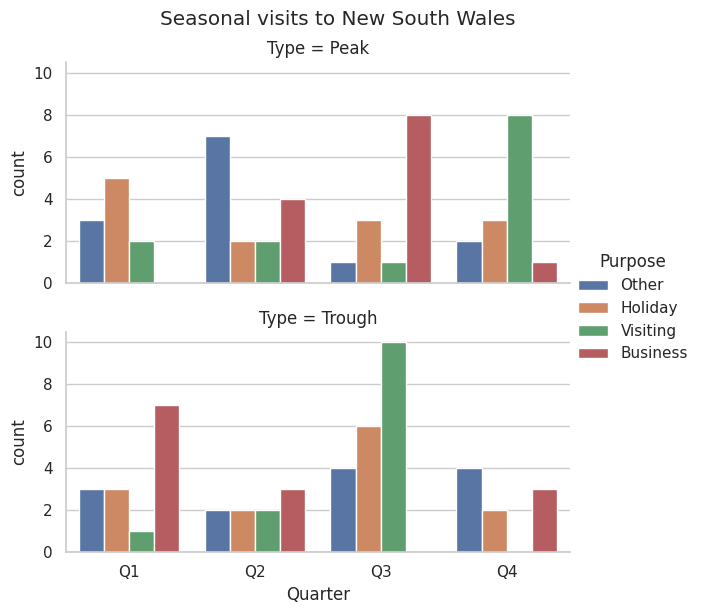

In [ ]:
fg = sns.catplot(
    data=peak_trough_purposes,
    kind="count",
    x="Quarter",
    hue="Purpose",
    row="Type",
    height=3,
    aspect=2,
)
fg.figure.suptitle("Seasonal visits to New South Wales", y=1.02)
fg.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

We can look at the data differently (choose what suits you best):

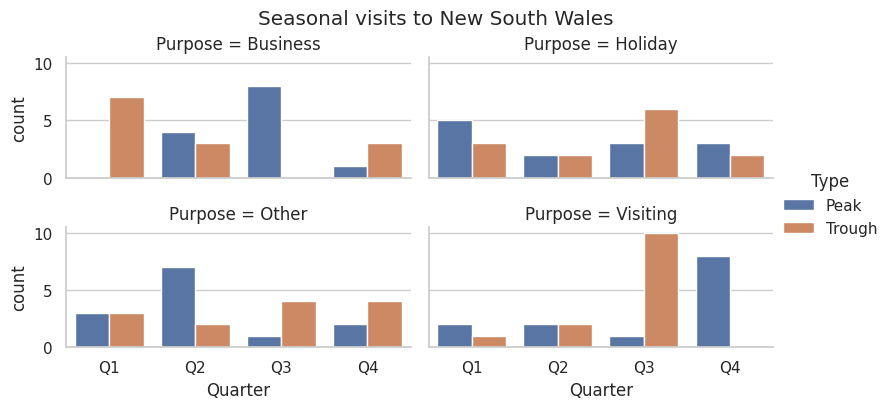

In [ ]:
fg = sns.catplot(
    data=peak_trough_purposes,
    kind="count",
    x="Quarter",
    hue="Type",
    col="Purpose",
    col_wrap=2,
    height=2,
    aspect=2,
)
fg.figure.suptitle("Seasonal visits to New South Wales", y=1.02)
fg.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

#### Interpretation

We can see how annual cycles, holidays, and work calendars shape regional tourism patterns:

- **Business** travel:
    - Demand tends to *peak in Q3* (winter/spring), possibly due to mid-year conferences, events, or business cycle changes.
    - Slowdowns observed in *Q1*, suggesting a post-holiday lull (reduced activity).
- **Holiday** travel:
    - Shows strong *Q1 peaks*, indicating a surge after New Year (likely due to school holidays or summer breaks).
    - Dips in *Q3* marking off-peak times as routines resume.
- **Other** category:
    - Generally exhibits weaker seasonality.
    - Slight tendency for peaks in *Q2* may suggest non-traditional activities or flexible timing.
    - Troughs in *Q3–Q4* might be linked to fewer such events.
- **Visiting** (friends/relatives):
    - Exhibits a sharp *Q4 peak*, likely influenced by family gatherings during holidays.
    - Dips in *Q3* when such visits appear less common.

Lastly, we can inspect features of $R_t$ the remainder component:

- `spike`: Measures the "spikiness" or presence of extreme values in the time series. "Are there irregular one-off bursts left over?"

In [ ]:
(
    nsw_features[["spike", "Region"]]
    .groupby("Region")
    .describe()
    .sort_values(("spike", "mean"), ascending=False)
)

spike                                                   \
                       count         mean          std        min         25%   
Region                                                                          
Sydney                   4.0  1941.375975  2225.791846  21.025811  415.234123   
South Coast              4.0   185.718729   297.317639   0.943206   19.244290   
North Coast NSW          4.0   185.708527   227.999779   1.589061   23.210747   
Hunter                   4.0    85.779266    77.651509   1.882650   38.564003   
Central NSW              4.0    34.152536    30.645959   2.149548   15.218870   
Central Coast            4.0    24.102699    35.042445   0.077582    0.709654   
The Murray               4.0     9.229750     9.037915   0.200647    4.852913   
Riverina                 4.0     8.339095     9.711796   0.273369    3.844130   
New England North West   4.0     5.355341     3.685281   0.892531    3.172603   
Capital Country          4.0     5.133984     3.986054   1.001431    2.078584   
Blue Mountains           4.0     4.369644     3.805698   0.036253    2.076045   
Snowy Mountains          4.0     4.011694     5.523905   0.099636    1.044857   
Outback NSW              4.0     2.664047     3.189023   0.006938    0.246519   

                                                               
                                50%          75%          max  
Region                                                         
Sydney                  1389.542164  2915.684016  4965.393761  
South Coast               56.834197   223.308636   628.263317  
North Coast NSW          121.907847   284.405627   497.429353  
Hunter                    79.433336   126.648599   182.367741  
Central NSW               30.635132    49.568798    73.190333  
Central Coast             10.827200    34.220244    74.678814  
The Murray                 7.515776    11.892613    21.686799  
Riverina                   5.311284     9.806249    22.460440  
New England North West     5.684755     7.867493     9.159323  
Capital Country            5.484154     8.539554     8.566200  
Blue Mountains             4.309300     6.602899     8.823723  
Snowy Mountains            1.885900     4.852737    12.175339  
Outback NSW                1.913937     4.331466     6.821374

- The **most unpredictable Region is Sydney**; since it has the highest remainder component $R_t$ as evident by the `spike` feature.
- We can see **Snowy Mountains** being low in `spike`iness feature; indicatin high reliability in the pattern of visits to it.

---

Other features of shape are:

- `linearity`: Measures how well changes in the series follow a straight line trend (from quadratic regression coefficients).
- `curvature`: Measures the degree of curvature in the trend component (from quadratic regression coefficients).

Other features:

- `e_acf1`: The autocorrelation at lag 1 of the remainder (residual) component, indicating short-term dependence in what's left over after removing trend/seasonality.
- `e_acf10`: The sum of squared autocorrelations from lag 1 to 10 of the remainder, capturing longer-term autocorrelation in the remainder.

Note descriptions were obtained by using `help(tsfeatures.stl_features)`.